In [10]:
pip install scikit-learn

In [11]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df=pd.read_csv('question_ans_analysis.csv')
print("First 5 rows:")
print(df.head())
print("\nInfo:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\\s]', '', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

df["clean_question"] = df["question_text"].apply(clean_text)
X_text = df["clean_question"]
numeric_features = [
    "total_students_attempted",
    "correct_attempts",
    "incorrect_attempts"
]

X_numeric = df[numeric_features]
categorical_features = ["cognitive_level_bloom"]
X_cat = df[categorical_features]
y = df["difficulty_label"]
X_text_train, X_text_test, X_num_train, X_num_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_text,
    X_numeric,
    X_cat,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_text_train_tfidf = vectorizer.fit_transform(X_text_train)
X_text_test_tfidf = vectorizer.transform(X_text_test)
# Create the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the categorical data
X_cat_train_encoded = encoder.fit_transform(X_cat_train)
X_cat_test_encoded = encoder.transform(X_cat_test)
scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)
X_train_final = np.hstack((X_text_train_tfidf.toarray(), X_num_train_scaled, X_cat_train_encoded))
X_test_final = np.hstack((X_text_test_tfidf.toarray(), X_num_test_scaled, X_cat_test_encoded))
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0
)

lr_model.fit(X_train_final, y_train)

y_pred_lr = lr_model.predict(X_test_final)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_model.fit(X_train_final, y_train)

y_pred_dt = dt_model.predict(X_test_final)

print("\n===== Decision Tree =====")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))
# Save the Decision Tree model
joblib.dump(dt_model, "dt_model.pkl")

# Save the preprocessors
joblib.dump(vectorizer, "tfidf.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

print("Decision Tree model and preprocessors saved successfully!")

First 5 rows:
                                       question_text           subject  \
0    Solve the quadratic equation scenario number 1.       Mathematics   
1     Implement binary search for scenario number 2.  Computer Science   
2      Apply Newton law to system scenario number 3.           Physics   
3  Evaluate matrix determinant for scenario numbe...       Mathematics   
4    Solve the quadratic equation scenario number 5.       Mathematics   

  cognitive_level_bloom  readability_score  word_count  sentence_count  \
0                create              77.49          22               1   
1            understand              45.01          17               2   
2                create              89.84          36               1   
3              remember              44.38          17               1   
4            understand              54.48          23               2   

   time_taken_minutes  total_students_attempted  correct_attempts  \
0                  23      

Top 20 Feature Importances for Decision Tree Model:


,Feature,Importance
4002,incorrect_attempts,0.376146
4001,correct_attempts,0.282553
4003,cognitive_level_bloom_analyze,0.164112
4004,cognitive_level_bloom_apply,0.154126
4006,cognitive_level_bloom_evaluate,0.010962
4005,cognitive_level_bloom_create,0.004268
4008,cognitive_level_bloom_understand,0.001402
4007,cognitive_level_bloom_remember,0.001189
842,calculateefficiencyofmachinewithscenarionumber...,0.000764
1407,computecircuitresistanceforscenarionumber3424,0.000762


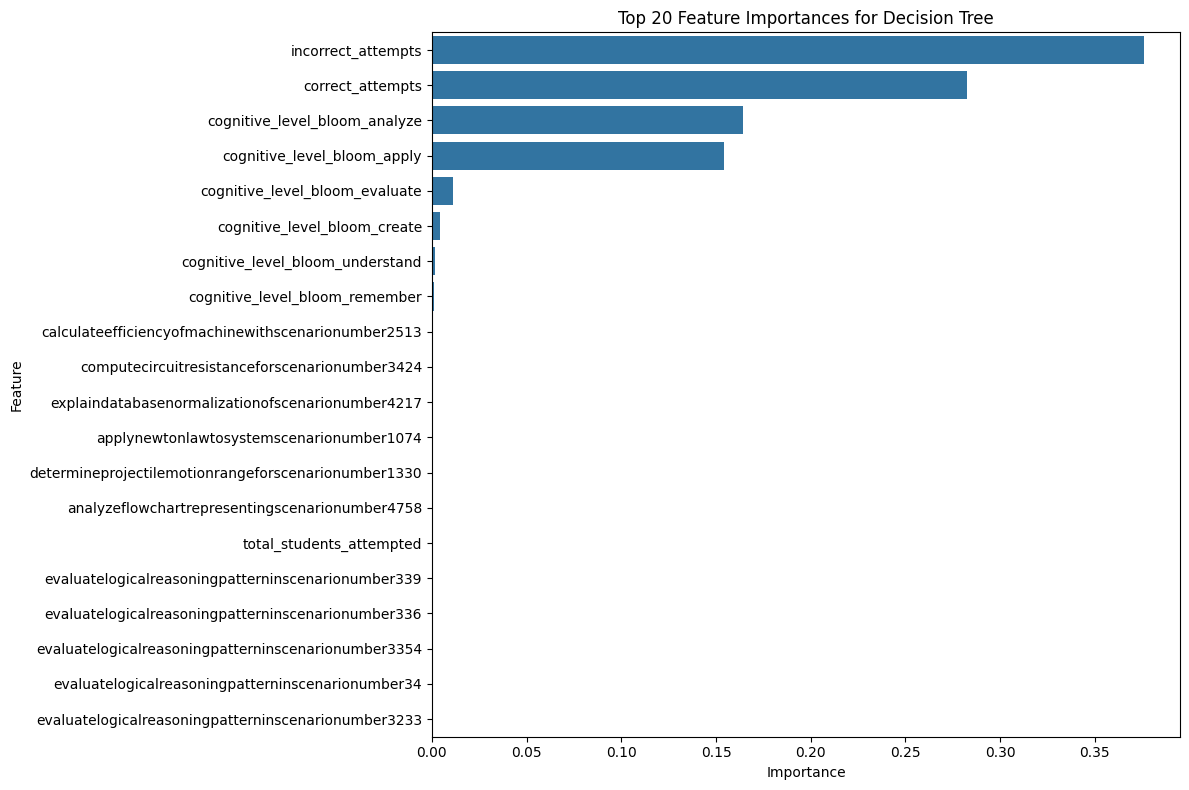

In [12]:
# Get feature importances from the Decision Tree model
feature_importances = dt_model.feature_importances_

# Get feature names for TF-IDF features
text_feature_names = vectorizer.get_feature_names_out()

# Get feature names for one-hot encoded categorical features
cat_feature_names = encoder.get_feature_names_out(categorical_features)

# Combine all feature names in the correct order
all_feature_names = np.concatenate([
    text_feature_names,
    numeric_features,
    cat_feature_names
])

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Feature Importances for Decision Tree Model:")
display(importance_df.head(20))

# Optional: Visualize the top N features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances for Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

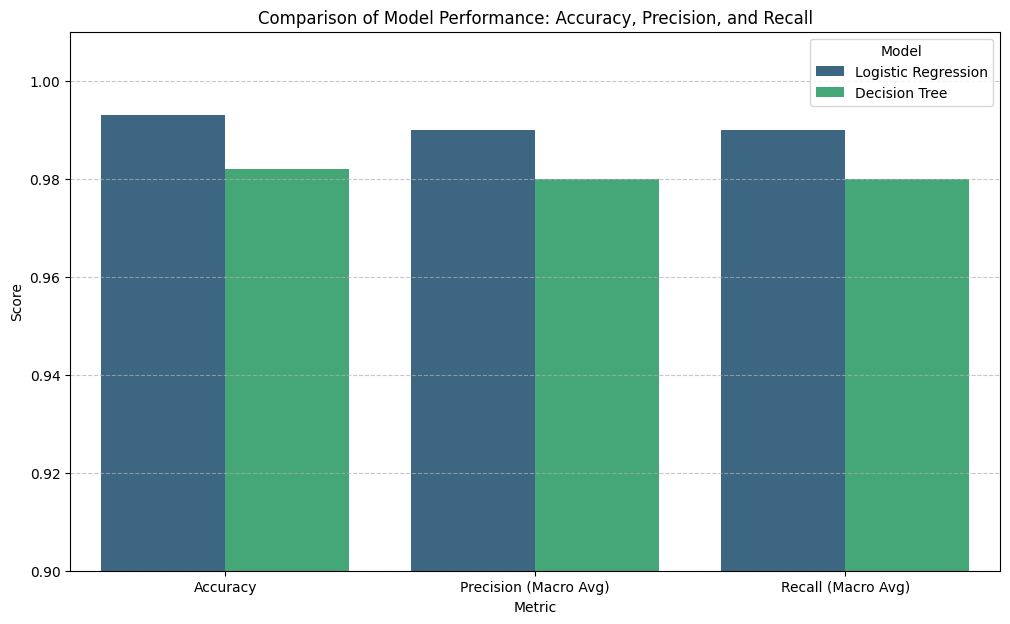

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Metrics extracted from previous output
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Logistic Regression', 'Decision Tree', 'Logistic Regression', 'Decision Tree'],
    'Metric': ['Accuracy', 'Accuracy', 'Precision (Macro Avg)', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'Recall (Macro Avg)'],
    'Score': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        0.99, # From LR classification report macro avg precision
        0.98, # From DT classification report macro avg precision
        0.99, # From LR classification report macro avg recall
        0.98  # From DT classification report macro avg recall
    ]
}

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df, palette='viridis')
plt.title('Comparison of Model Performance: Accuracy, Precision, and Recall')
plt.ylabel('Score')
plt.ylim(0.9, 1.01) # Set y-axis limits to focus on the high scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [14]:
import joblib

# Load the Decision Tree model
loaded_dt_model = joblib.load('dt_model.pkl')
print('Decision Tree model loaded successfully.')

# Load the TF-IDF vectorizer
loaded_tfidf_vectorizer = joblib.load('tfidf.pkl')
print('TF-IDF vectorizer loaded successfully.')

Decision Tree model loaded successfully.
TF-IDF vectorizer loaded successfully.


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set using the loaded model
y_pred_loaded_dt = loaded_dt_model.predict(X_test_final)

print("===== Loaded Decision Tree Model Evaluation =====")
print("Accuracy:", accuracy_score(y_test, y_pred_loaded_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_loaded_dt))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_loaded_dt))

===== Loaded Decision Tree Model Evaluation =====
Accuracy: 0.982

Classification Report:

              precision    recall  f1-score   support

        easy       1.00      0.97      0.98       330
        hard       0.99      0.99      0.99       341
      medium       0.96      0.99      0.97       329

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


Confusion Matrix:

[[320   0  10]
 [  0 337   4]
 [  1   3 325]]


Top 20 Feature Importances for Logistic Regression Model:


,Feature,Importance
4002,incorrect_attempts,5.256480
4001,correct_attempts,4.530216
4007,cognitive_level_bloom_remember,1.867360
4008,cognitive_level_bloom_understand,1.604265
4004,cognitive_level_bloom_apply,1.290053
4003,cognitive_level_bloom_analyze,0.907845
4006,cognitive_level_bloom_evaluate,0.809653
4005,cognitive_level_bloom_create,0.782929
3458,findderivativeoffunctionscenarionumber4299,0.683940
2281,determineprojectilemotionrangeforscenarionumbe...,0.597689


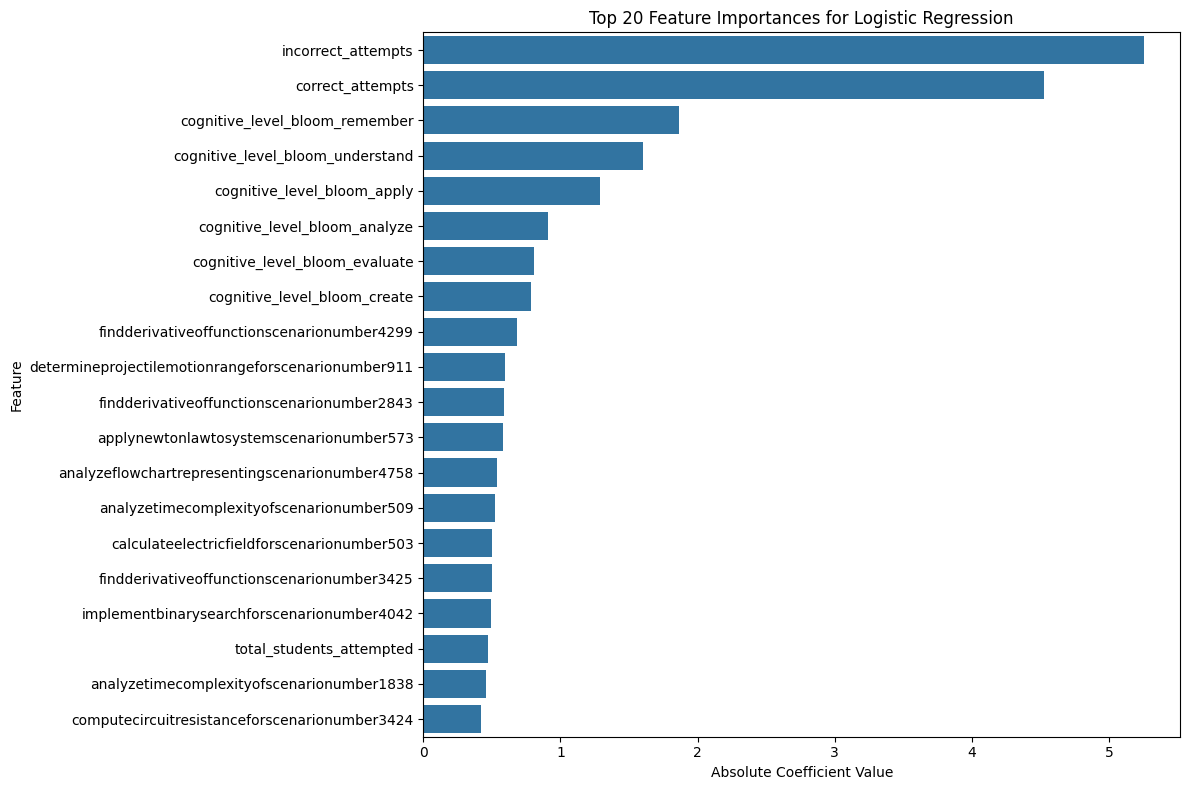

In [16]:
lr_feature_importances = lr_model.coef_[0]

# Create a DataFrame for better visualization
lr_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': np.abs(lr_feature_importances) # Use absolute values for importance
})

# Sort by importance in descending order
lr_importance_df = lr_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Feature Importances for Logistic Regression Model:")
display(lr_importance_df.head(20))

# Visualize the top N features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=lr_importance_df.head(20))
plt.title('Top 20 Feature Importances for Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

These confusion matrices visually represent how well each model classified the different difficulty levels. The diagonal elements show correct predictions, while off-diagonal elements indicate misclassifications.